In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import io
import numpy as np
from scipy.stats import pearsonr, spearmanr
from scipy import stats

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (MODIFICAR AQUÍ)
# ==========================================

# Elige el sensor para el análisis actual: 's2', 'l89' o 's1'
SENSOR_ACTUAL = 'l89' 

METODO_CORR = 'spearman'    # Opciones: 'pearson', 'spearman'

# Definimos listas de variables de interés (fijas + dinámicas según sensor)
vars_suelo = [
    'Piezometer_na_groundwater-depth_m',
    'Piezometer_na_temperature_degreeC',
    'TEROS12_15cm_soil-temperature_degreeC',
    'TEROS21_25cm_soil-temperature_degreeC',
    'TEROS12_30cm_soil-temperature_degreeC',
    'TEROS21_35cm_soil-temperature_degreeC',
    'TEROS12_48cm_soil-temperature_degreeC',
    'TEROS12_15cm_water-content_m3/m3',
    'TEROS12_30cm_water-content_m3/m3',
    'TEROS12_48cm_water-content_m3/m3',
    'TEROS12_15cm_saturation-extract-ec_mS/cm',
    'TEROS12_30cm_saturation-extract-ec_mS/cm',    
    'TEROS12_48cm_saturation-extract-ec_mS/cm'
]

# Configuración Estética
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# ==========================================
# 2. DICCIONARIO DE MAPEO (Técnico -> Tesis)
# ==========================================
# Este diccionario traduce las columnas del CSV a etiquetas legibles para los gráficos.
NAME_MAPPING = {
    # --- TEROS 12  ---
    'TEROS12_15cm_water-content_m3/m3': 'Cont. agua (15cm) [m³/m³]',
    'TEROS12_15cm_soil-temperature_degreeC': 'Temp. suelo (15cm) [°C]',
    'TEROS12_15cm_saturation-extract-ec_mS/cm': 'Cond. electrica (15cm) [mS/cm]',
    'TEROS12_30cm_water-content_m3/m3': 'Cont. agua (30cm) [m³/m³]',
    'TEROS12_30cm_soil-temperature_degreeC': 'Temp. suelo (30cm) [°C]',
    'TEROS12_30cm_saturation-extract-ec_mS/cm': 'Cond. electrica (30cm) [mS/cm]',
    'TEROS12_48cm_water-content_m3/m3': 'Cont. agua (48cm) [m³/m³]',
    'TEROS12_48cm_soil-temperature_degreeC': 'Temp. suelo (48cm) [°C]',
    'TEROS12_48cm_saturation-extract-ec_mS/cm': 'Cond. electrica (48cm) [mS/cm]',

    # --- TEROS 21 ---
    'TEROS21_25cm_matric-potential_kPa': 'Potencial matricial (25cm) [kPa]',
    'TEROS21_25cm_soil-temperature_degreeC': 'Temp. suelo (25cm) [°C]',
    'TEROS21_35cm_matric-potential_kPa': 'Potencial matricial (35cm) [kPa]',
    'TEROS21_35cm_soil-temperature_degreeC': 'Temp. suelo (35cm) [°C]',

    # --- Piezómetro ---
    'Piezometer_na_temperature_degreeC': 'Temp. agua subterranea [°C]',
    'Piezometer_na_groundwater-depth_m': 'Prof. nivel freatico [m]',
    'Piezometer_na_groundwater-level_masl': 'Cota nivel freatico [m.s.n.m.]',
    
    # --- Landsat 8/9 ---
    'l89_SR_B2': 'L89 banda azul',
    'l89_SR_B3': 'L89 banda verde',
    'l89_SR_B4': 'L89 banda roja',
    'l89_SR_B5': 'L89 banda NIR',
    'l89_SR_B6': 'L89 banda SWIR1',
    'l89_SR_B7': 'L89 banda SWIR 2',
    'l89_ST_B10': 'L89 LST [K]',
    'l89_ndvi': 'L89 NDVI',
    'l89_ndwi': 'L89 NDWI',
    'l89_mndwi': 'L89 MNDWI',
    'l89_ndmi': 'L89 NDMI',
    'l89_ndmi2': 'L89 NDMI2',
    'l89_srt': 'L89 STR',
    'l89_brightness': 'L89 TCT brillo',
    'l89_greenness': 'L89 TCT verdor',
    'l89_wetness': 'L89 TCT humedad',
    
    # --- Sentinel-2 ---
    's2_B2': 'S2 banda azul',
    's2_B3': 'S2 banda verde',
    's2_B4': 'S2 banda roja',
    's2_B8': 'S2 banda NIR',
    's2_B11': 'S2 banda SWIR1',
    's2_B12': 'S2 banda SWIR2',
    's2_ndvi': 'S2 NDVI',
    's2_ndwi': 'S2 NDWI',
    's2_mndwi': 'S2 MNDWI',
    's2_ndmi': 'S2 NDMI',
    's2_ndmi2': 'S2 NDMI2',
    's2_srt': 'S2 STR',
    's2_brightness': 'S2 TCT brillo',
    's2_greenness': 'S2 TCT verdor',
    's2_wetness': 'S2 TCT humedad',
    
    # --- Sentinel-1 ---
    's1_VV': 'S1 backscatter VV [dB]',
    's1_VH': 'S1 backscatter VH [dB]',
    's1_vh_vv_ratio': 'S1 VH/VV',
    's1_ndpol': 'S1 Normalized Polarization'
}

# Definimos qué columnas clave indican que el sensor "estuvo presente" ese día
SENSOR_KEY_COLS = {
    's2': 's2_B2',       # Si esta banda existe, S2 pasó ese día
    'l89': 'l89_SR_B2',  # Si esta banda existe, L89 pasó ese día
    's1': 's1_VV'        # Si esta banda existe, S1 pasó ese día
}

print(f"Configuración cargada. Analizando sensor: {SENSOR_ACTUAL.upper()}")

Configuración cargada. Analizando sensor: L89


In [2]:
# ==========================================
# 3. CARGA DE DATOS
# ==========================================

df = pd.read_csv('../data/processed/04_compiled/dataset_compiled_SDH1.csv')

# 1. Convertir Timestamps
df['Timestamps'] = pd.to_datetime(df['Timestamps'])

# 2. Filtrado Modular por Sensor
columna_clave = SENSOR_KEY_COLS.get(SENSOR_ACTUAL)

if columna_clave:
    # Filtramos el DF para quedarnos solo con filas donde el sensor tiene datos
    df_sensor = df.dropna(subset=[columna_clave]).copy()
    
    print(f"Total registros originales: {len(df)}")
    print(f"Registros válidos para {SENSOR_ACTUAL}: {len(df_sensor)}")
else:
    print("Error: Sensor no reconocido en SENSOR_KEY_COLS")

Total registros originales: 605
Registros válidos para l89: 60


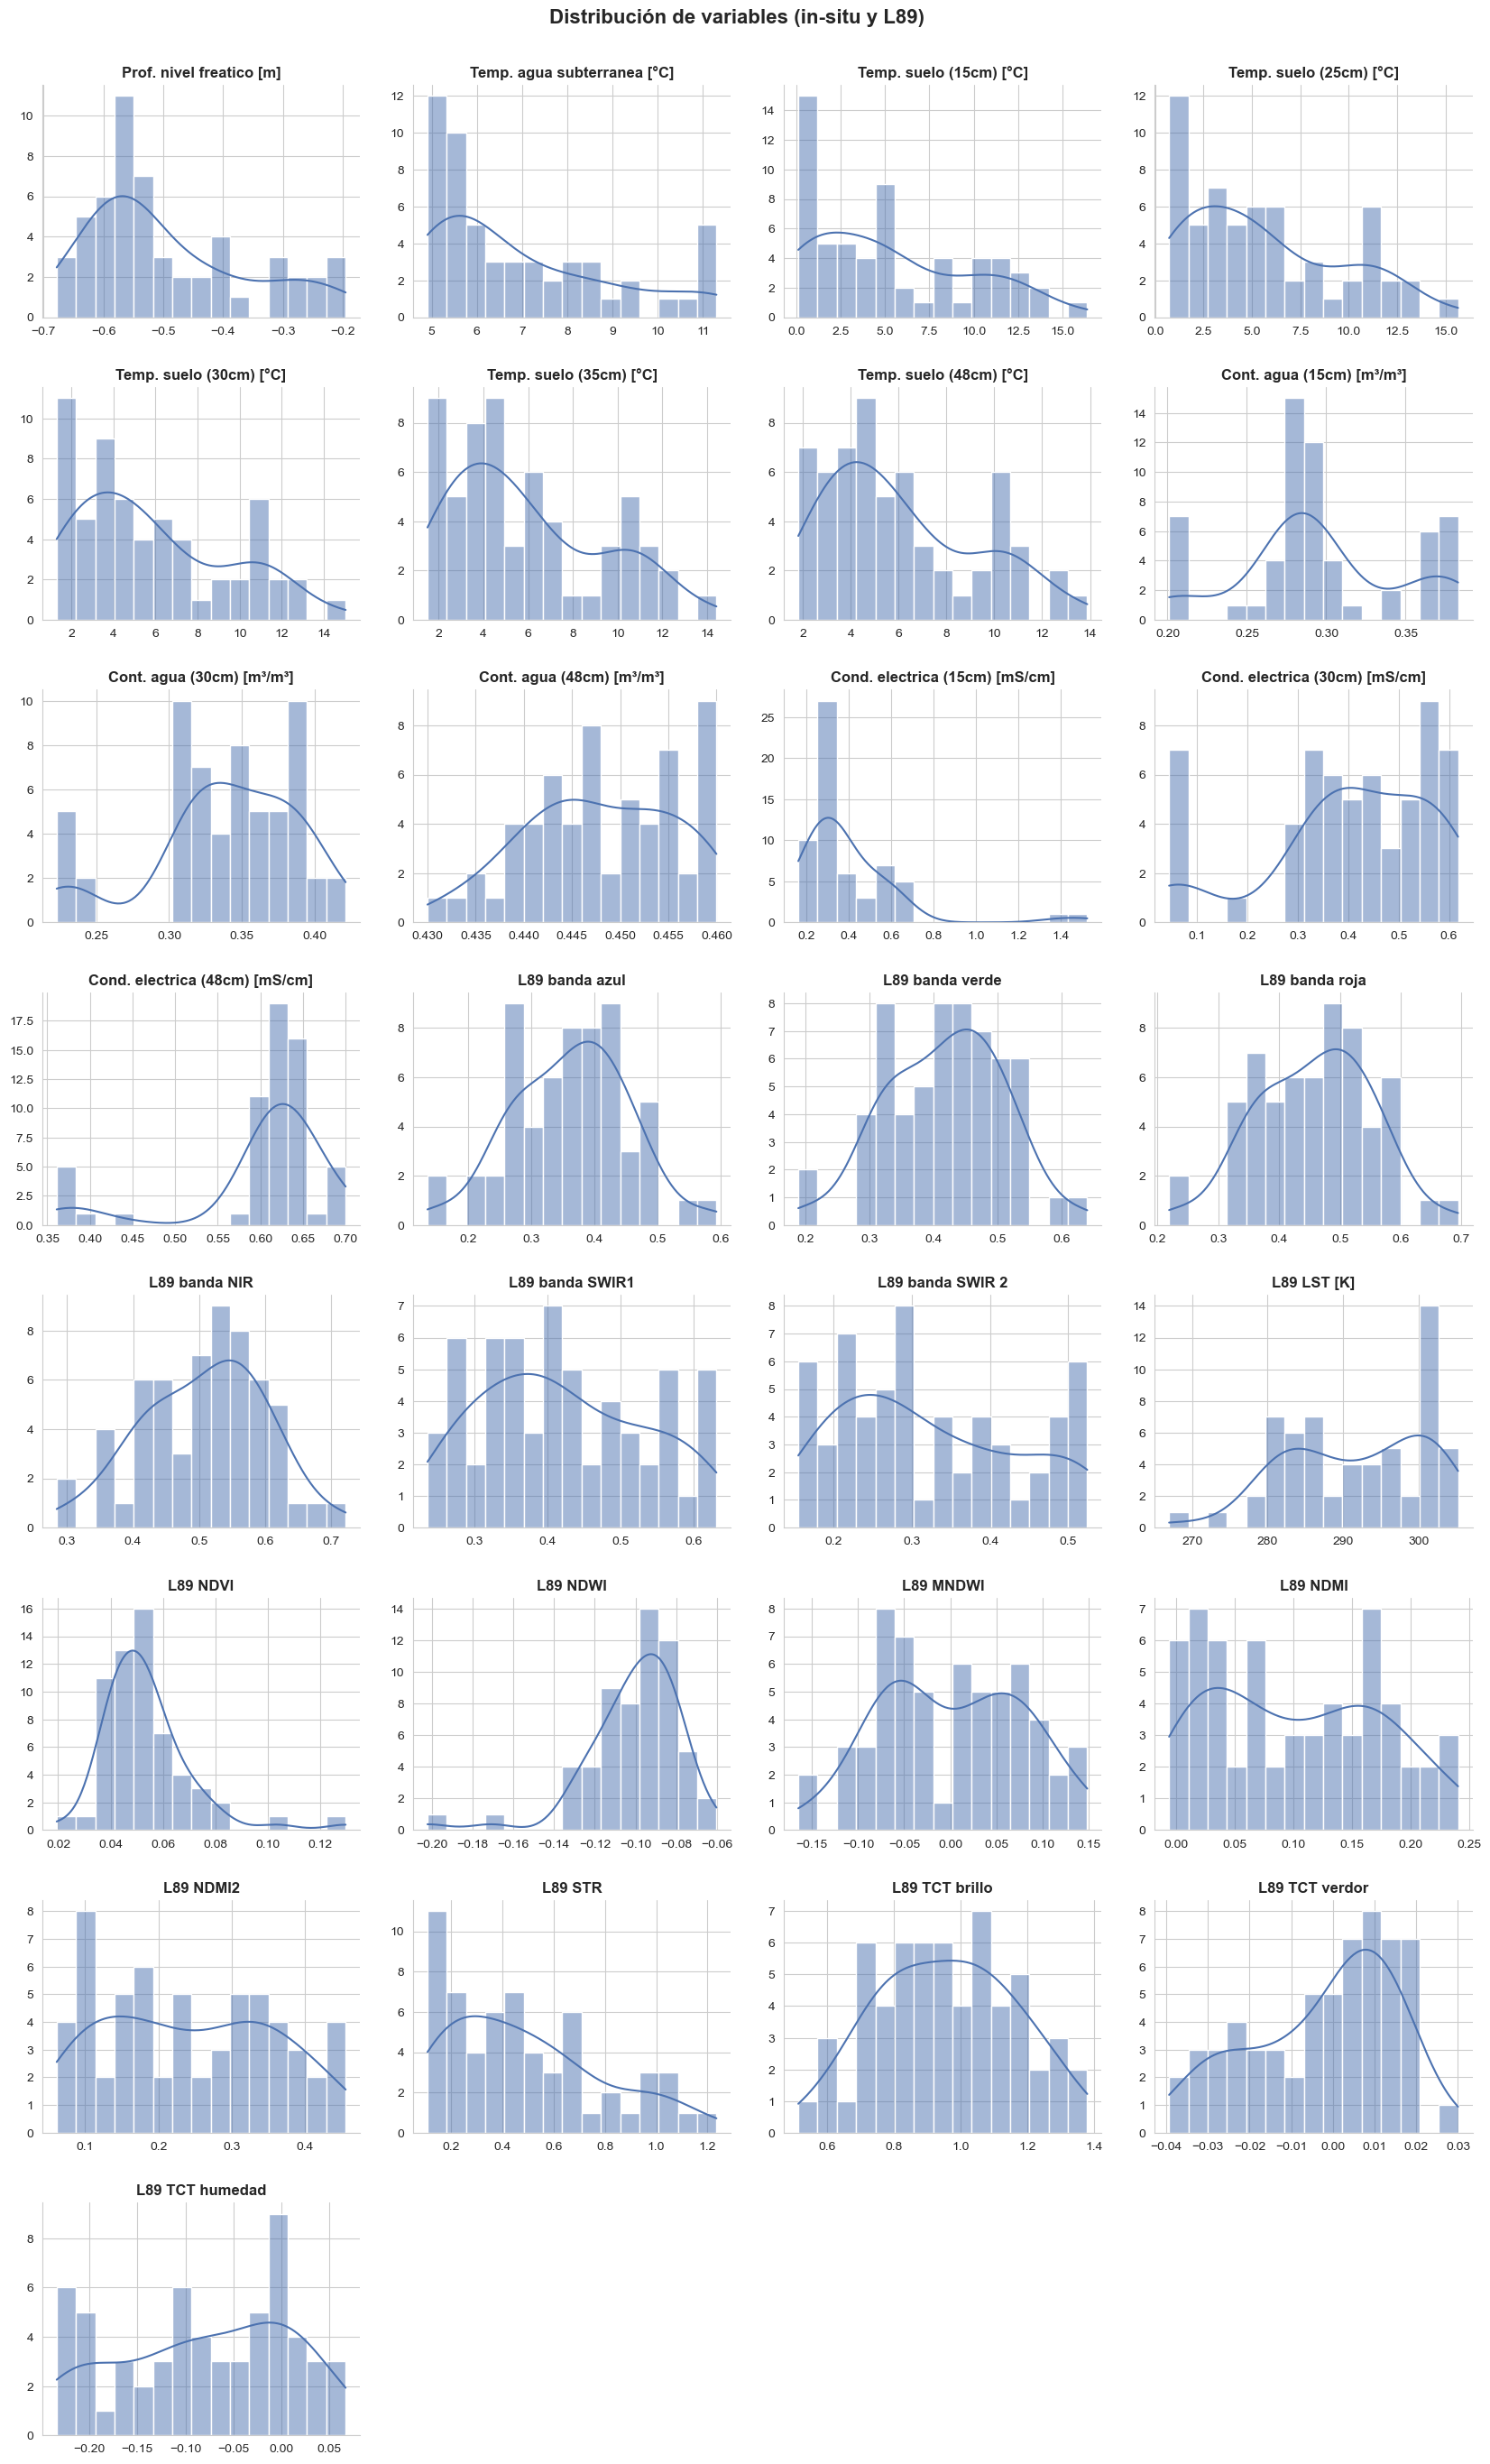

In [3]:
# ==========================================
# 4. SELECCIÓN DE VARIABLES A GRAFICAR
# ==========================================

# Selección dinámica de columnas del satélite
vars_satelite = [col for col in df.columns if col.startswith(SENSOR_ACTUAL + '_')]

# Combinamos todo
vars_to_plot = vars_suelo + vars_satelite

# ==========================================
# 5. GRAFICACIÓN (FACETGRID)
# ==========================================

# Preparamos datos para FacetGrid (Formato 'Long' o 'Melted')
# Solo tomamos las columnas que existen en el dataframe actual
valid_vars = [v for v in vars_to_plot if v in df_sensor.columns]

df_melted = df_sensor[valid_vars].melt(var_name='Variable_Tecnica', value_name='Valor')

# Aplicamos el MAPEO de nombres (Usa el nombre original si no está en el diccionario)
df_melted['Variable'] = df_melted['Variable_Tecnica'].map(lambda x: NAME_MAPPING.get(x, x))

# Crear el Gráfico
g = sns.FacetGrid(
    df_melted, 
    col="Variable",      # Una sub-gráfica por variable
    col_wrap=4,          # Máximo 4 gráficos por fila
    sharex=False,        # Cada hist tiene su propia escala X
    sharey=False,        # Cada hist tiene su propia escala Y
    height=3.5,          # Altura de cada subgráfico
    aspect=1.2           # Proporción ancho/alto
)

# Dibujar histogramas con curva de densidad (kde)
g.map(sns.histplot, "Valor", kde=True, bins=15, color="#4C72B0", edgecolor="white")

# Ajustes finales de títulos
g.set_titles("{col_name}", size=12, weight='bold')
g.set_axis_labels("", "")
plt.subplots_adjust(top=0.95,
                    hspace=0.3)
g.fig.suptitle(f'Distribución de variables (in-situ y {SENSOR_ACTUAL.upper()})', fontsize=16, weight='bold')

plt.show()

/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_15791/166777446.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = corr_matrix.applymap(lambda x: f"{x:.2f}")


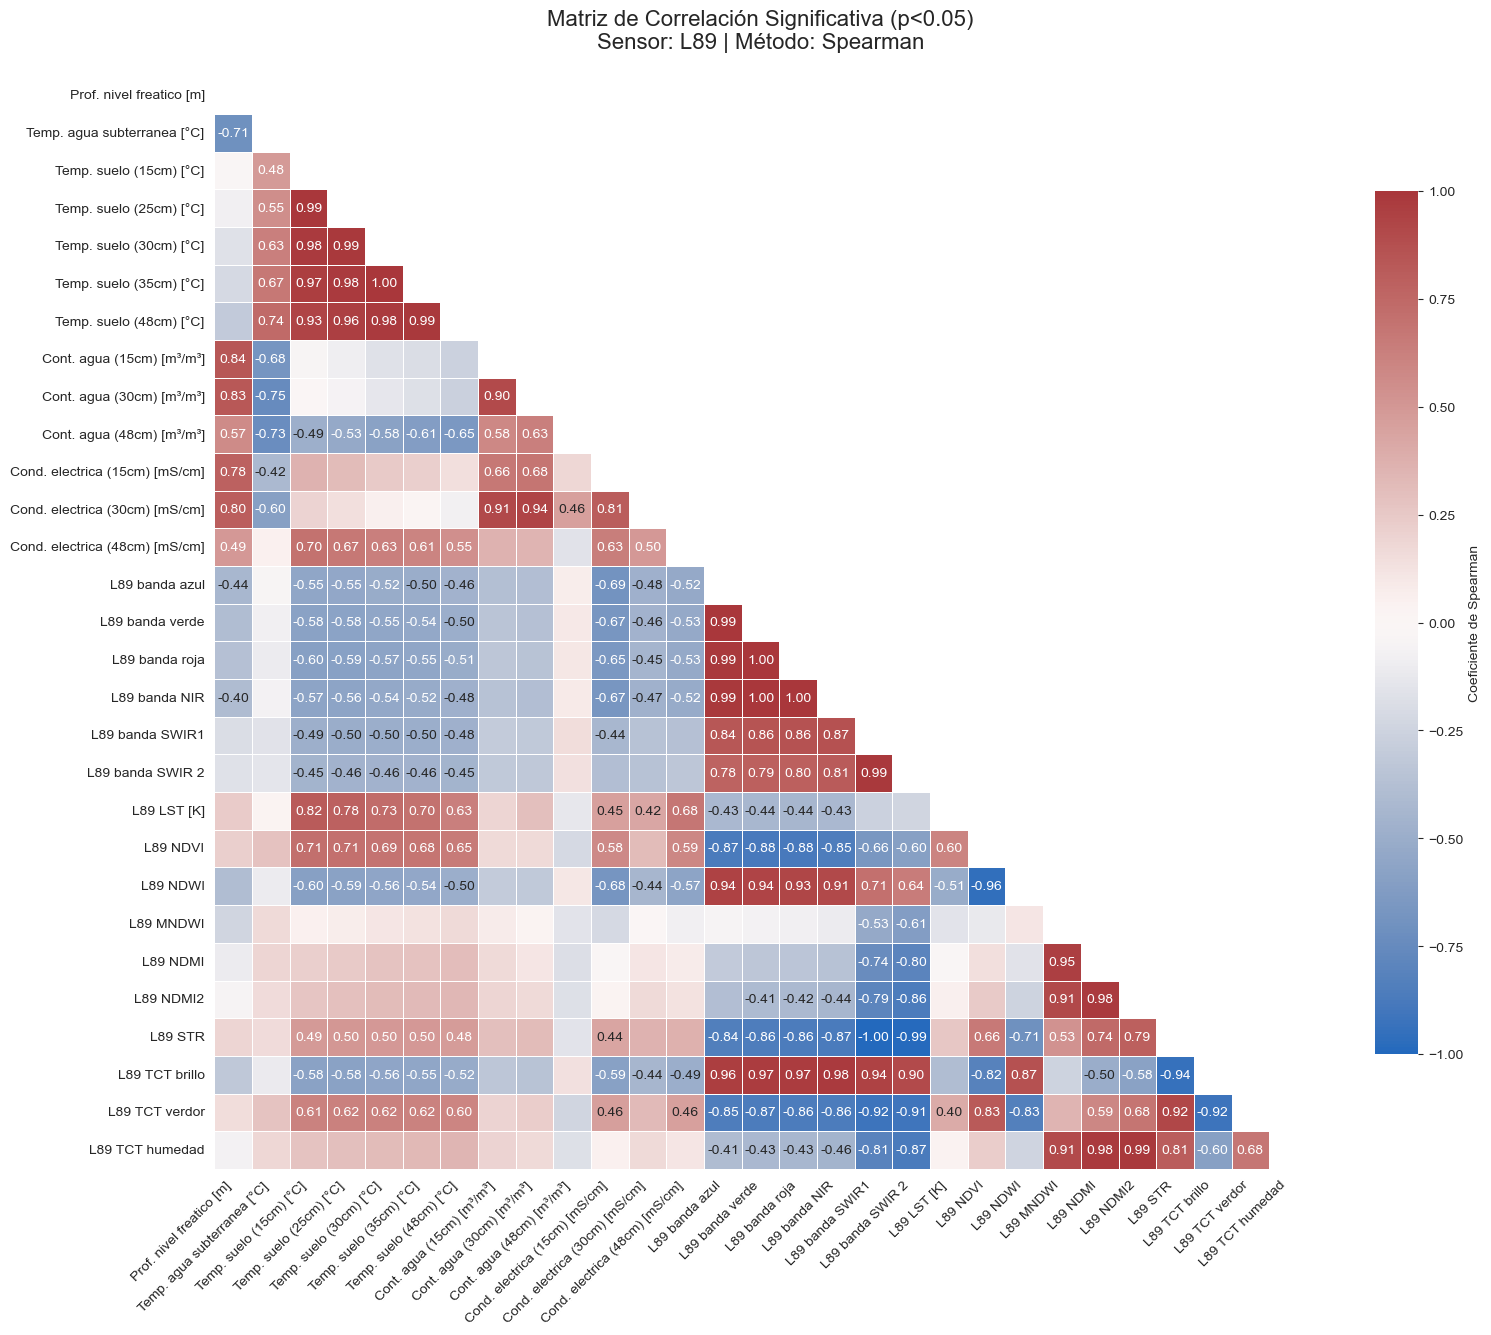

In [4]:
def plot_correlation_heatmap(df, sensor, metodo='spearman', vars_insitu_selected=None):
    """
    Genera un heatmap de correlación filtrado por sensor y significancia estadística (p < 0.05).
    """
    
    # 1. Identificar columnas del sensor y filtrar filas
    # Usamos las claves definidas anteriormente para saber si el sensor pasó ese día
    key_col = SENSOR_KEY_COLS.get(sensor)
    
    if not key_col:
        print(f"Error: Sensor '{sensor}' no configurado en SENSOR_KEY_COLS.")
        return

    # Filtramos: Solo días donde el sensor tiene datos
    df_clean = df.dropna(subset=[key_col]).copy()
    
    # 2. Seleccionar variables (In-situ + Satelitales del sensor actual)
    cols_satelite = [c for c in df.columns if c.startswith(f"{sensor}_")]
    
    # Si no se pasan vars in-situ específicas, usar todas las disponibles en el DF que sean numéricas
    if vars_insitu_selected is None:
        # Excluir timestamps y columnas de otros sensores
        cols_total = [c for c in df_clean.columns if c in vars_suelo or c in cols_satelite]
    else:
        cols_total = vars_insitu_selected + cols_satelite
        
    # Validar que las columnas existan
    cols_existentes = [c for c in cols_total if c in df_clean.columns]
    data_corr = df_clean[cols_existentes]

    # 3. Renombrar columnas para el gráfico (Usando NAME_MAPPING global)
    data_corr = data_corr.rename(columns=NAME_MAPPING)
    
    # 4. Cálculo de Correlación y Matriz de P-Valores
    # Pandas .corr() calcula coeficientes, pero necesitamos scipy para p-valores
    corr_matrix = data_corr.corr(method=metodo)
    p_value_matrix = pd.DataFrame(np.ones(corr_matrix.shape), columns=corr_matrix.columns, index=corr_matrix.index)
    
    # Iteramos sobre las columnas para calcular p-valor par a par
    for col1 in data_corr.columns:
        for col2 in data_corr.columns:
            if col1 == col2:
                continue
            
            # Limpiamos NaNs solo para este par de variables (pairwise deletion)
            temp_df = data_corr[[col1, col2]].dropna()
            
            if len(temp_df) > 2: # Necesitamos al menos 3 puntos
                if metodo == 'pearson':
                    stat, p = pearsonr(temp_df[col1], temp_df[col2])
                else:
                    stat, p = spearmanr(temp_df[col1], temp_df[col2])
                
                p_value_matrix.loc[col1, col2] = p
            else:
                p_value_matrix.loc[col1, col2] = 1.0 # No significativo si no hay datos

    # 5. Crear máscara para anotaciones (Solo mostrar si p < 0.05)
    # Creamos una matriz de TEXTO para las anotaciones
    annot_matrix = corr_matrix.applymap(lambda x: f"{x:.2f}")
    
    # Borramos el texto donde p_value >= 0.05 y la corr < |n|
    mask_significancia = p_value_matrix >= 0.05
    mask_magnitud = corr_matrix.abs() < 0.4
    annot_matrix[mask_significancia | mask_magnitud] = ""
    
    # 6. Configuración Visual
    sns.set_style("white")
    plt.figure(figsize=(16, 14))
    
    # Máscara para el triángulo superior
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Generar Heatmap
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=annot_matrix.values, # Usamos nuestra matriz de texto condicional
        fmt='',                    # Importante: formato vacío porque ya pasamos strings
        cmap='vlag',               # Paleta Divergente
        center=0, vmin=-1, vmax=1,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .7, "label": f"Coeficiente de {metodo.capitalize()}"}
    )
    
    plt.title(f'Matriz de Correlación Significativa (p<0.05)\nSensor: {sensor.upper()} | Método: {metodo.capitalize()}', fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ==========================================
# EJECUCIÓN
# ==========================================

# Llamada a la función
plot_correlation_heatmap(
    df=df,  # Asegúrate de pasar el DataFrame original completo (antes de filtrar)
    sensor=SENSOR_ACTUAL, 
    metodo=METODO_CORR,
    vars_insitu_selected=vars_suelo
)

In [34]:
# ==========================================
# 1. DICCIONARIO DE ESTILOS (Consistencia Visual)
# ==========================================
# Asignamos un Color (Hex) y un Marcador a cada variable única.
# Si una variable no está aquí, el script le asignará un estilo por defecto.
ESTILOS_GENERICOS = {
    # --- In situ ---
    'water-content':        {'color': '#17becf', 'marker': 'P'},
    'soil-temperature':     {'color': '#9467bd', 'marker': 'v'},
    'saturation-extract':   {'color': '#8c564b', 'marker': 'X'},
    'groundwater':          {'color': '#595959', 'marker': 'o'},
    
    # --- Satelitales ---
    'ndvi':     {'color': '#2ca02c', 'marker': '^'}, 
    'brightness':      {'color': '#ff7f0e', 'marker': 'p'},
    'srt':       {'color': '#bcbd22', 'marker': '*'},
    'B2':      {'color': '#1f77b4', 'marker': 'o'},
    'VV':       {'color': '#7f7f7f', 'marker': '>'},
    'VH':       {'color': "#858585", 'marker': '<'}
}

# ==========================================
# 2. DEFINICIÓN DE PARES A GRAFICAR
# ==========================================
# Tuplas: (Variable 1, Variable 2)

if SENSOR_ACTUAL == 'l89':
    PARES_A_GRAFICAR = [
        ('TEROS12_15cm_soil-temperature_degreeC', 'l89_ndvi'),
        ('TEROS12_15cm_soil-temperature_degreeC', 'l89_ST_B10'),
        ('TEROS12_15cm_saturation-extract-ec_mS/cm', 'l89_SR_B2'),
        ('TEROS12_15cm_saturation-extract-ec_mS/cm', 'l89_ndwi'),
        ('Piezometer_na_groundwater-depth_m', 'l89_srt'),
        ('Piezometer_na_groundwater-depth_m', 'l89_ndmi'),
        ('TEROS12_15cm_water-content_m3/m3', 'l89_brightness'),
        ('TEROS12_15cm_water-content_m3/m3', 'l89_srt'),
    ]
elif SENSOR_ACTUAL == 's2':
    PARES_A_GRAFICAR = [
        ('TEROS12_30cm_soil-temperature_degreeC', 'l89_ST_B10'),
        ('TEROS12_30cm_soil-temperature_degreeC', 's2_ndvi'),
        ('TEROS12_48cm_saturation-extract-ec_mS/cm', 'l89_ST_B10'),
        ('TEROS12_48cm_saturation-extract-ec_mS/cm', 's2_ndvi'),
        ('Piezometer_na_groundwater-depth_m', 'TEROS12_15cm_saturation-extract-ec_mS/cm'),
        ('Piezometer_na_groundwater-depth_m', 'TEROS12_15cm_water-content_m3/m3'),
        ('TEROS12_15cm_water-content_m3/m3', 's2_srt'),
        ('TEROS12_15cm_water-content_m3/m3', 's2_brightness'),
    ]
elif SENSOR_ACTUAL == 's1':
    PARES_A_GRAFICAR = [
        ('TEROS12_30cm_soil-temperature_degreeC', 's1_VV'),
        ('TEROS12_30cm_soil-temperature_degreeC', 's1_VH'),
        ('TEROS12_48cm_saturation-extract-ec_mS/cm', 's1_VV'),
        ('TEROS12_48cm_saturation-extract-ec_mS/cm', 's1_VH'),
        ('Piezometer_na_groundwater-depth_m', 's1_VV'),
        ('Piezometer_na_groundwater-depth_m', 's1_VH'),
        ('TEROS12_15cm_water-content_m3/m3', 's1_VV'),
        ('TEROS12_15cm_water-content_m3/m3', 's1_VH'),
    ]

In [35]:
def plot_paired_timeseries_flexible(df, sensor, pairs_list, style_dict):
    """
    Grafica pares de series temporales usando estilos basados en coincidencias parciales.
    Ej: 'l89_ndvi' y 's2_ndvi' recibirán el mismo estilo definido bajo la clave 'ndvi'.
    """
    
    # --- Función auxiliar para buscar estilo ---
    def _obtener_estilo(nombre_variable, diccionario_estilos):
        # Itera sobre las palabras clave (ej: 'ndvi', 'water-content')
        for key, estilo in diccionario_estilos.items():
            if key in nombre_variable:
                return estilo
        # Si no encuentra coincidencia, devuelve estilo por defecto (gris)
        return {'color': 'gray', 'marker': '.'}

    # 1. Filtrado de Datos
    key_col = SENSOR_KEY_COLS.get(sensor)
    if not key_col:
        print(f"Sensor {sensor} no reconocido.")
        return

    df_plot = df.dropna(subset=[key_col]).copy()
    
    if df_plot.empty:
        print("No hay datos coincidentes para graficar.")
        return

    # 2. Estandarización Z-Score
    unique_vars = set([v for pair in pairs_list for v in pair])
    for col in unique_vars:
        if col in df_plot.columns:
            std_val = df_plot[col].std()
            if std_val != 0:
                df_plot[col] = (df_plot[col] - df_plot[col].mean()) / std_val
            else:
                df_plot[col] = 0

    # 3. Configuración del Layout
    n_pairs = len(pairs_list)
    cols = 2
    rows = int(np.ceil(n_pairs / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = axes.flatten() if n_pairs > 1 else [axes]
    
    sns.set_style("whitegrid")
    
    # 4. Iteración sobre los Pares
    for i, (var1, var2) in enumerate(pairs_list):
        ax = axes[i]
        vars_pair = [var1, var2]
        
        for var in vars_pair:
            if var in df_plot.columns:
                # AQUÍ USAMOS LA NUEVA LÓGICA FLEXIBLE
                estilo = _obtener_estilo(var, style_dict)
                nombre_legible = NAME_MAPPING.get(var, var)
                
                ax.plot(
                    df_plot['Timestamps'], 
                    df_plot[var],
                    color=estilo['color'],
                    marker=estilo['marker'],
                    linestyle='-',
                    linewidth=1.2,
                    markersize=4,
                    alpha=0.8,
                    label=nombre_legible
                )
        
        # Estética
        #ax.set_title(f'Comparativa {i+1}', fontsize=12, fontweight='bold', color='#333333')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
        ax.tick_params(axis='x', rotation=30, labelsize=9)
        ax.legend(loc='best', fontsize=9, frameon=True, facecolor='white', framealpha=0.9)
        ax.set_ylabel('Z-Score', fontsize=10)

    # Limpieza
    for k in range(i + 1, len(axes)):
        fig.delaxes(axes[k])
        
    plt.suptitle(f'Dinámica de Pares (Estilos Flexibles)\nSensor Base: {sensor.upper()}', fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

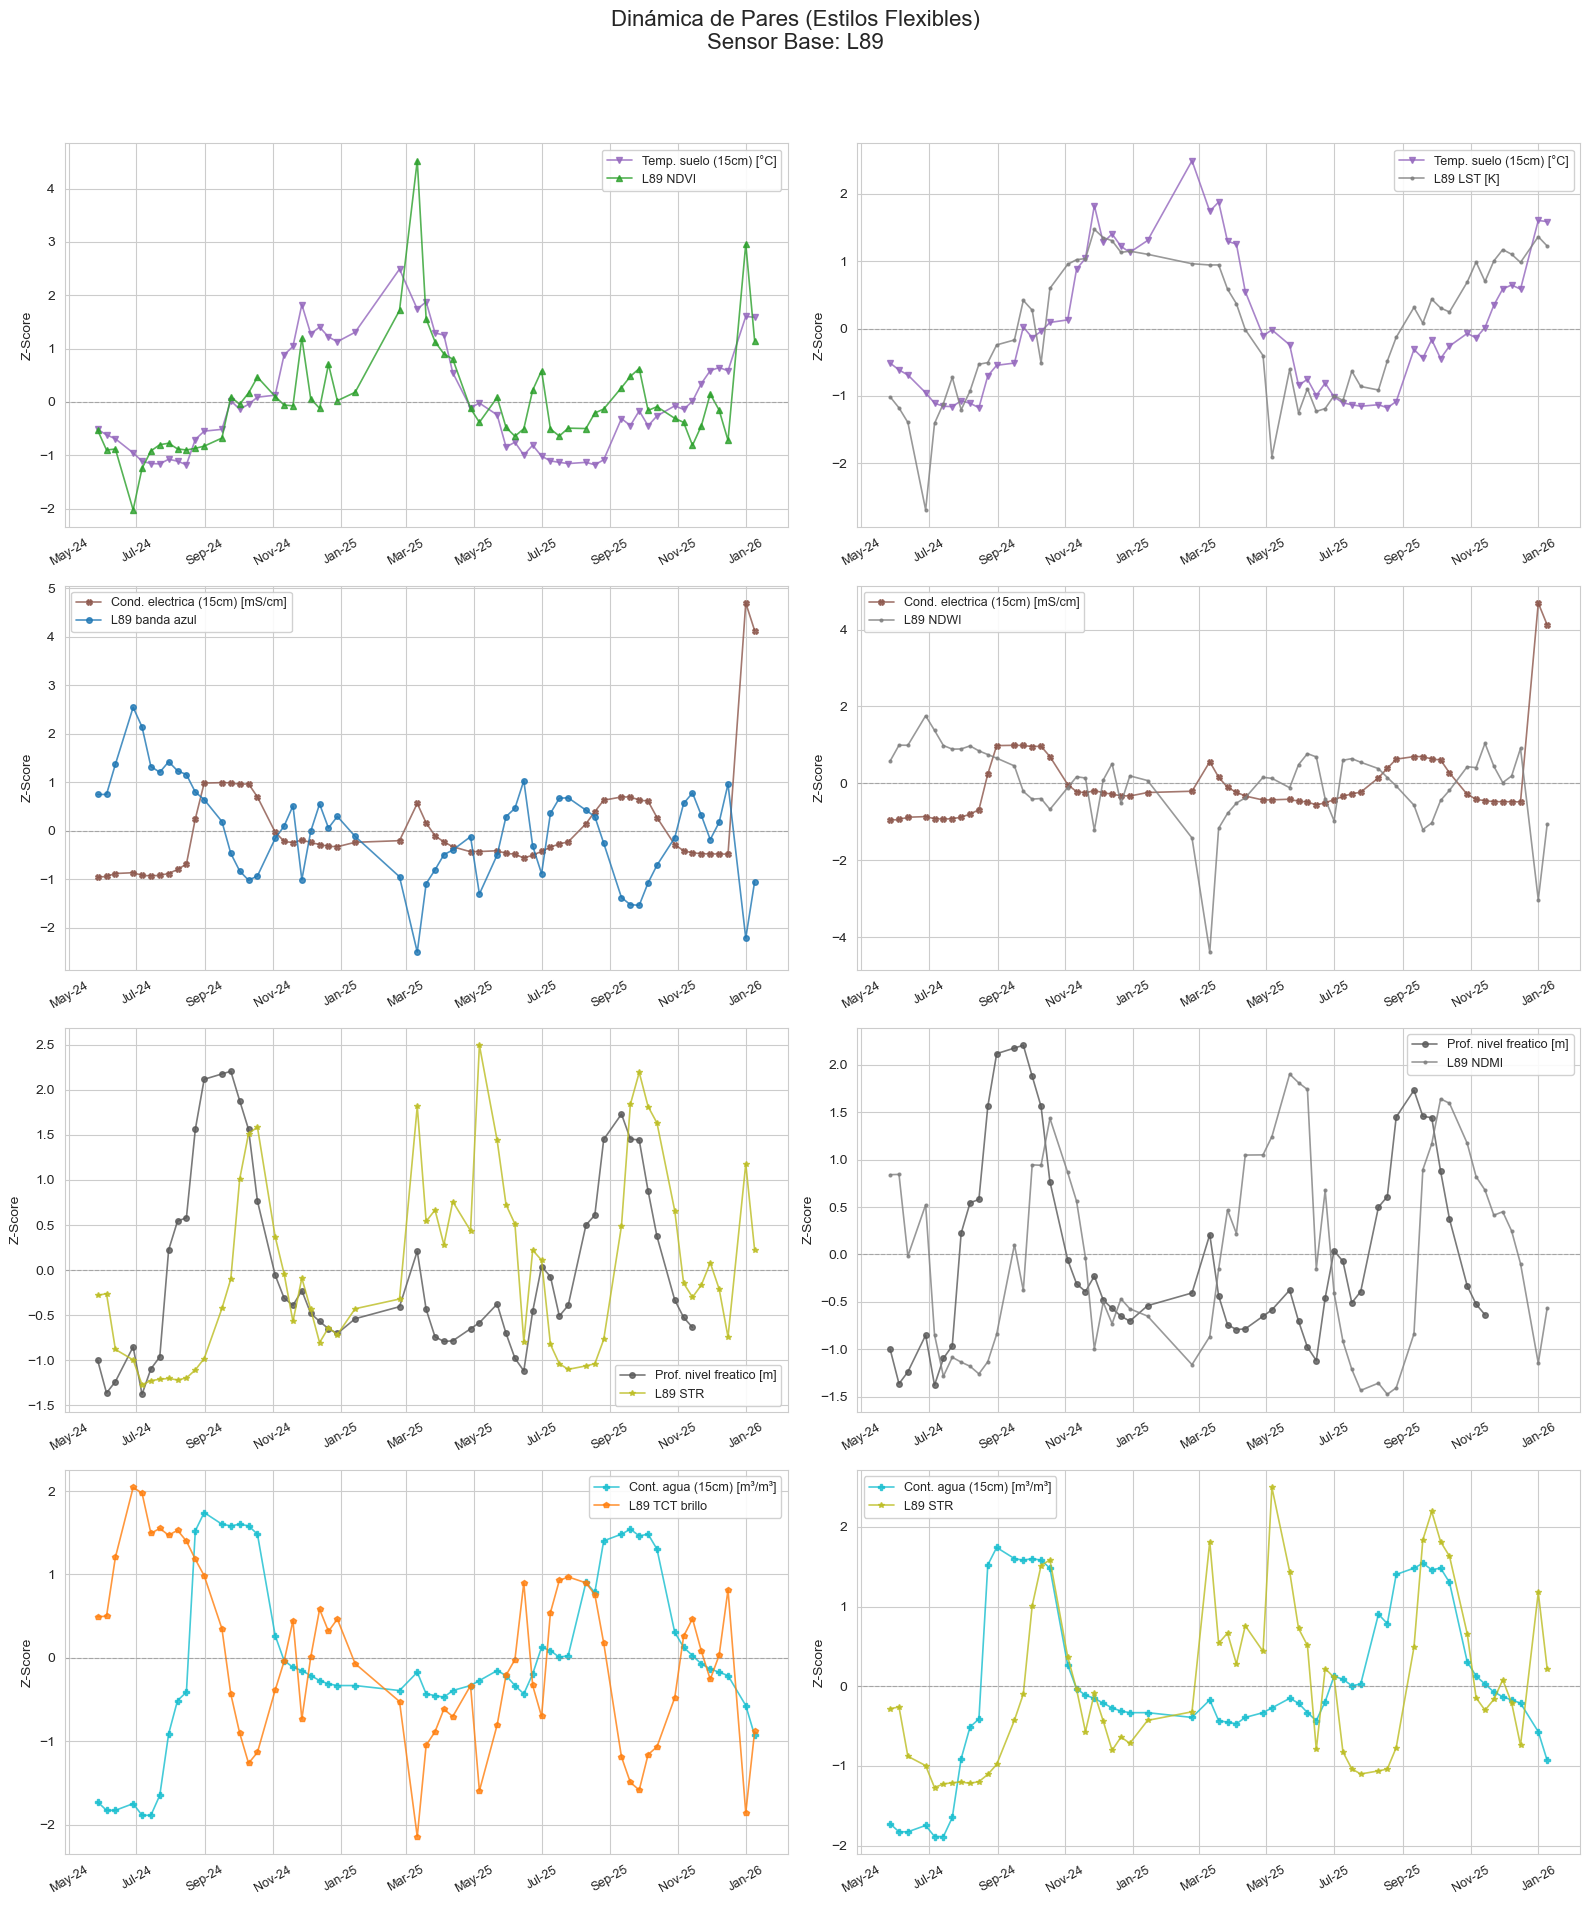

In [36]:
# ==========================================
# EJECUCIÓN
# ==========================================

# Aseguramos que las columnas de los pares existan en el estilo
# Si cambias 's2' por 'l89', asegúrate de actualizar la lista PARES_A_GRAFICAR
# con variables que empiecen por 'l89_'

# Ejecutar la función
plot_paired_timeseries_flexible(
    df=df, 
    sensor=SENSOR_ACTUAL,  # Variable global definida en Tarea 1
    pairs_list=PARES_A_GRAFICAR, 
    style_dict=ESTILOS_GENERICOS
)

Graficando pares para sensor: l89


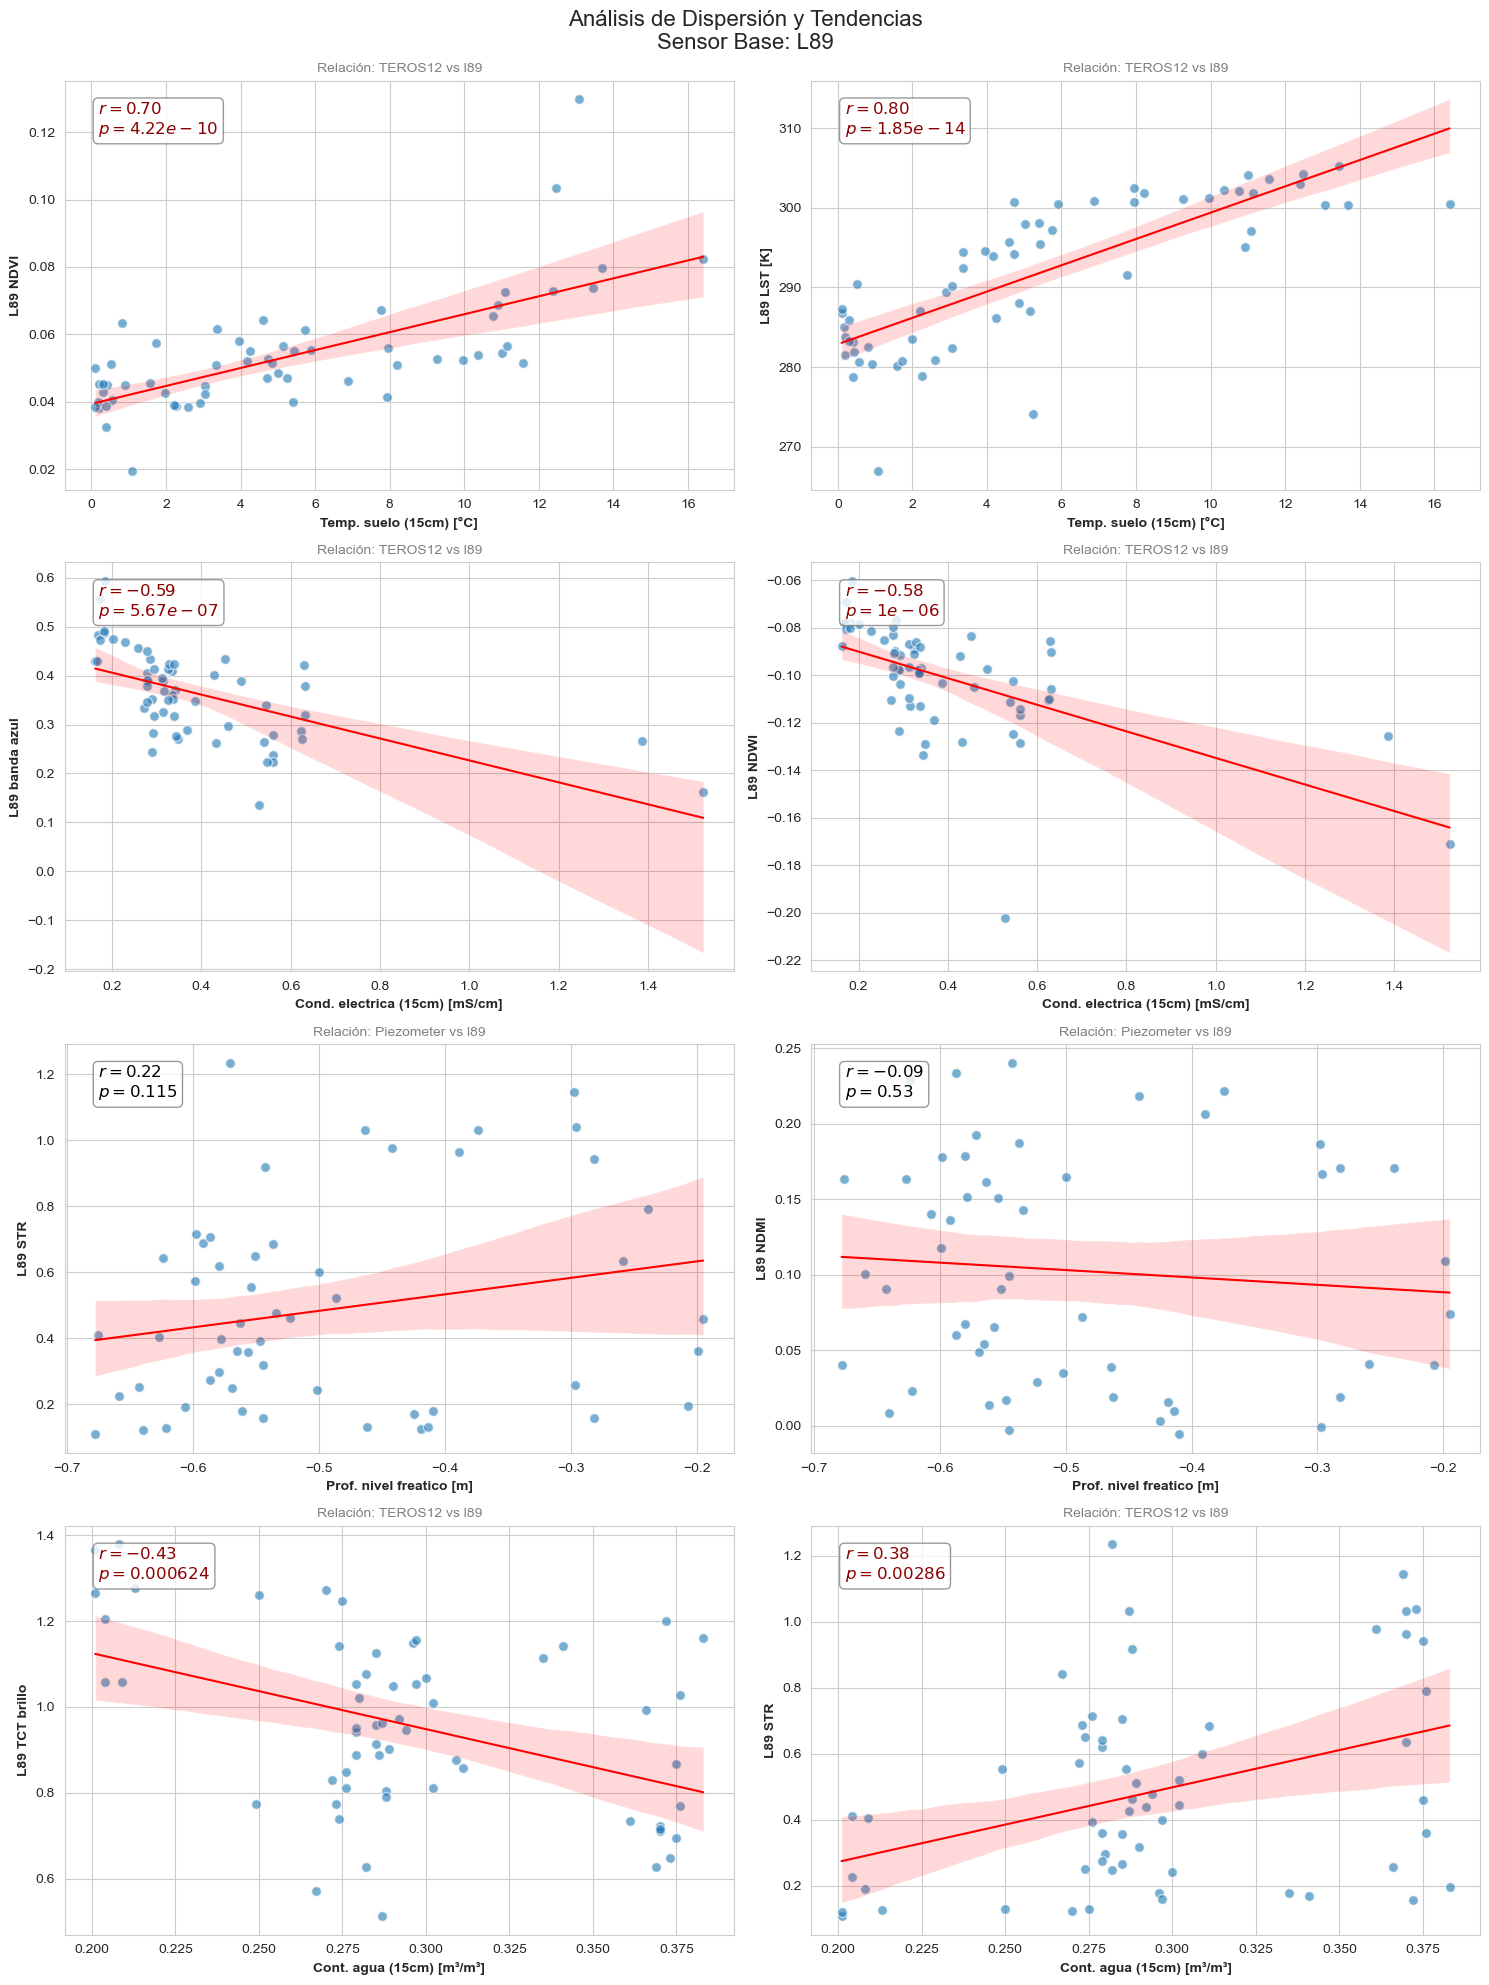

In [37]:
# ==========================================
# 2. FUNCIÓN DE GRAFICACIÓN DE DISPERSIÓN
# ==========================================
def plot_scatter_pairs(df, sensor, pairs_list):
    """
    Genera scatter plots con línea de regresión y estadísticas (r, p-value).
    """
    
    # Configuración de la figura
    n_pairs = len(pairs_list)
    cols = 2
    rows = int(n_pairs / cols) + (n_pairs % cols > 0)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    # Estilo limpio
    sns.set_style("whitegrid")
    
    for i, (x_var, y_var) in enumerate(pairs_list):
        ax = axes[i]
        
        # 1. Preparar Datos: Eliminación "Pairwise" de NaNs
        # Esto es crucial: Solo borramos filas si falta dato en ESTE par específico
        # Permite correlacionar S2 vs L89 solo en los días que coinciden
        subset = df[[x_var, y_var]].dropna()
        
        if len(subset) > 2: # Necesitamos mínimos puntos para regresión
            # 2. Calcular Estadísticas (Pearson)
            r, p = stats.pearsonr(subset[x_var], subset[y_var])
            
            # Texto de la anotación
            stats_text = f"$r = {r:.2f}$\n$p = {p:.3g}$"
            if p < 0.05:
                stats_color = 'darkred' # Destacar si es significativo
                weight = 'bold'
            else:
                stats_color = 'black'
                weight = 'normal'

            # 3. Graficar (Regplot incluye intervalo de confianza 95%)
            sns.regplot(
                data=subset, 
                x=x_var, 
                y=y_var, 
                ax=ax,
                scatter_kws={'s': 50, 'alpha': 0.6, 'edgecolor': 'w'},
                line_kws={'color': 'red', 'lw': 1.5}
            )
            
            # 4. Anotar estadísticas en el gráfico
            # Ubicación: Esquina superior izquierda (coords relativas 0.05, 0.95)
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                    fontsize=12, color=stats_color, fontweight=weight,
                    verticalalignment='top', bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
            
        else:
            ax.text(0.5, 0.5, "Datos insuficientes\npara este par", 
                    ha='center', va='center', transform=ax.transAxes, color='gray')

        # 5. Etiquetas "Elegantes"
        ax.set_xlabel(NAME_MAPPING.get(x_var, x_var), fontsize=10, fontweight='bold')
        ax.set_ylabel(NAME_MAPPING.get(y_var, y_var), fontsize=10, fontweight='bold')
        ax.set_title(f'Relación: {x_var.split("_")[0]} vs {y_var.split("_")[0]}', fontsize=10, color='gray')

    # Limpiar ejes vacíos
    for k in range(i + 1, len(axes)):
        fig.delaxes(axes[k])
        
    plt.suptitle(f'Análisis de Dispersión y Tendencias\nSensor Base: {sensor.upper()}', fontsize=16, y=0.99)
    plt.tight_layout()
    plt.show()

# ==========================================
# EJECUCIÓN
# ==========================================
# Se ejecuta usando la variable global SENSOR_ACTUAL definida al inicio del notebook
print(f"Graficando pares para sensor: {SENSOR_ACTUAL}")
plot_scatter_pairs(df, SENSOR_ACTUAL, PARES_A_GRAFICAR)

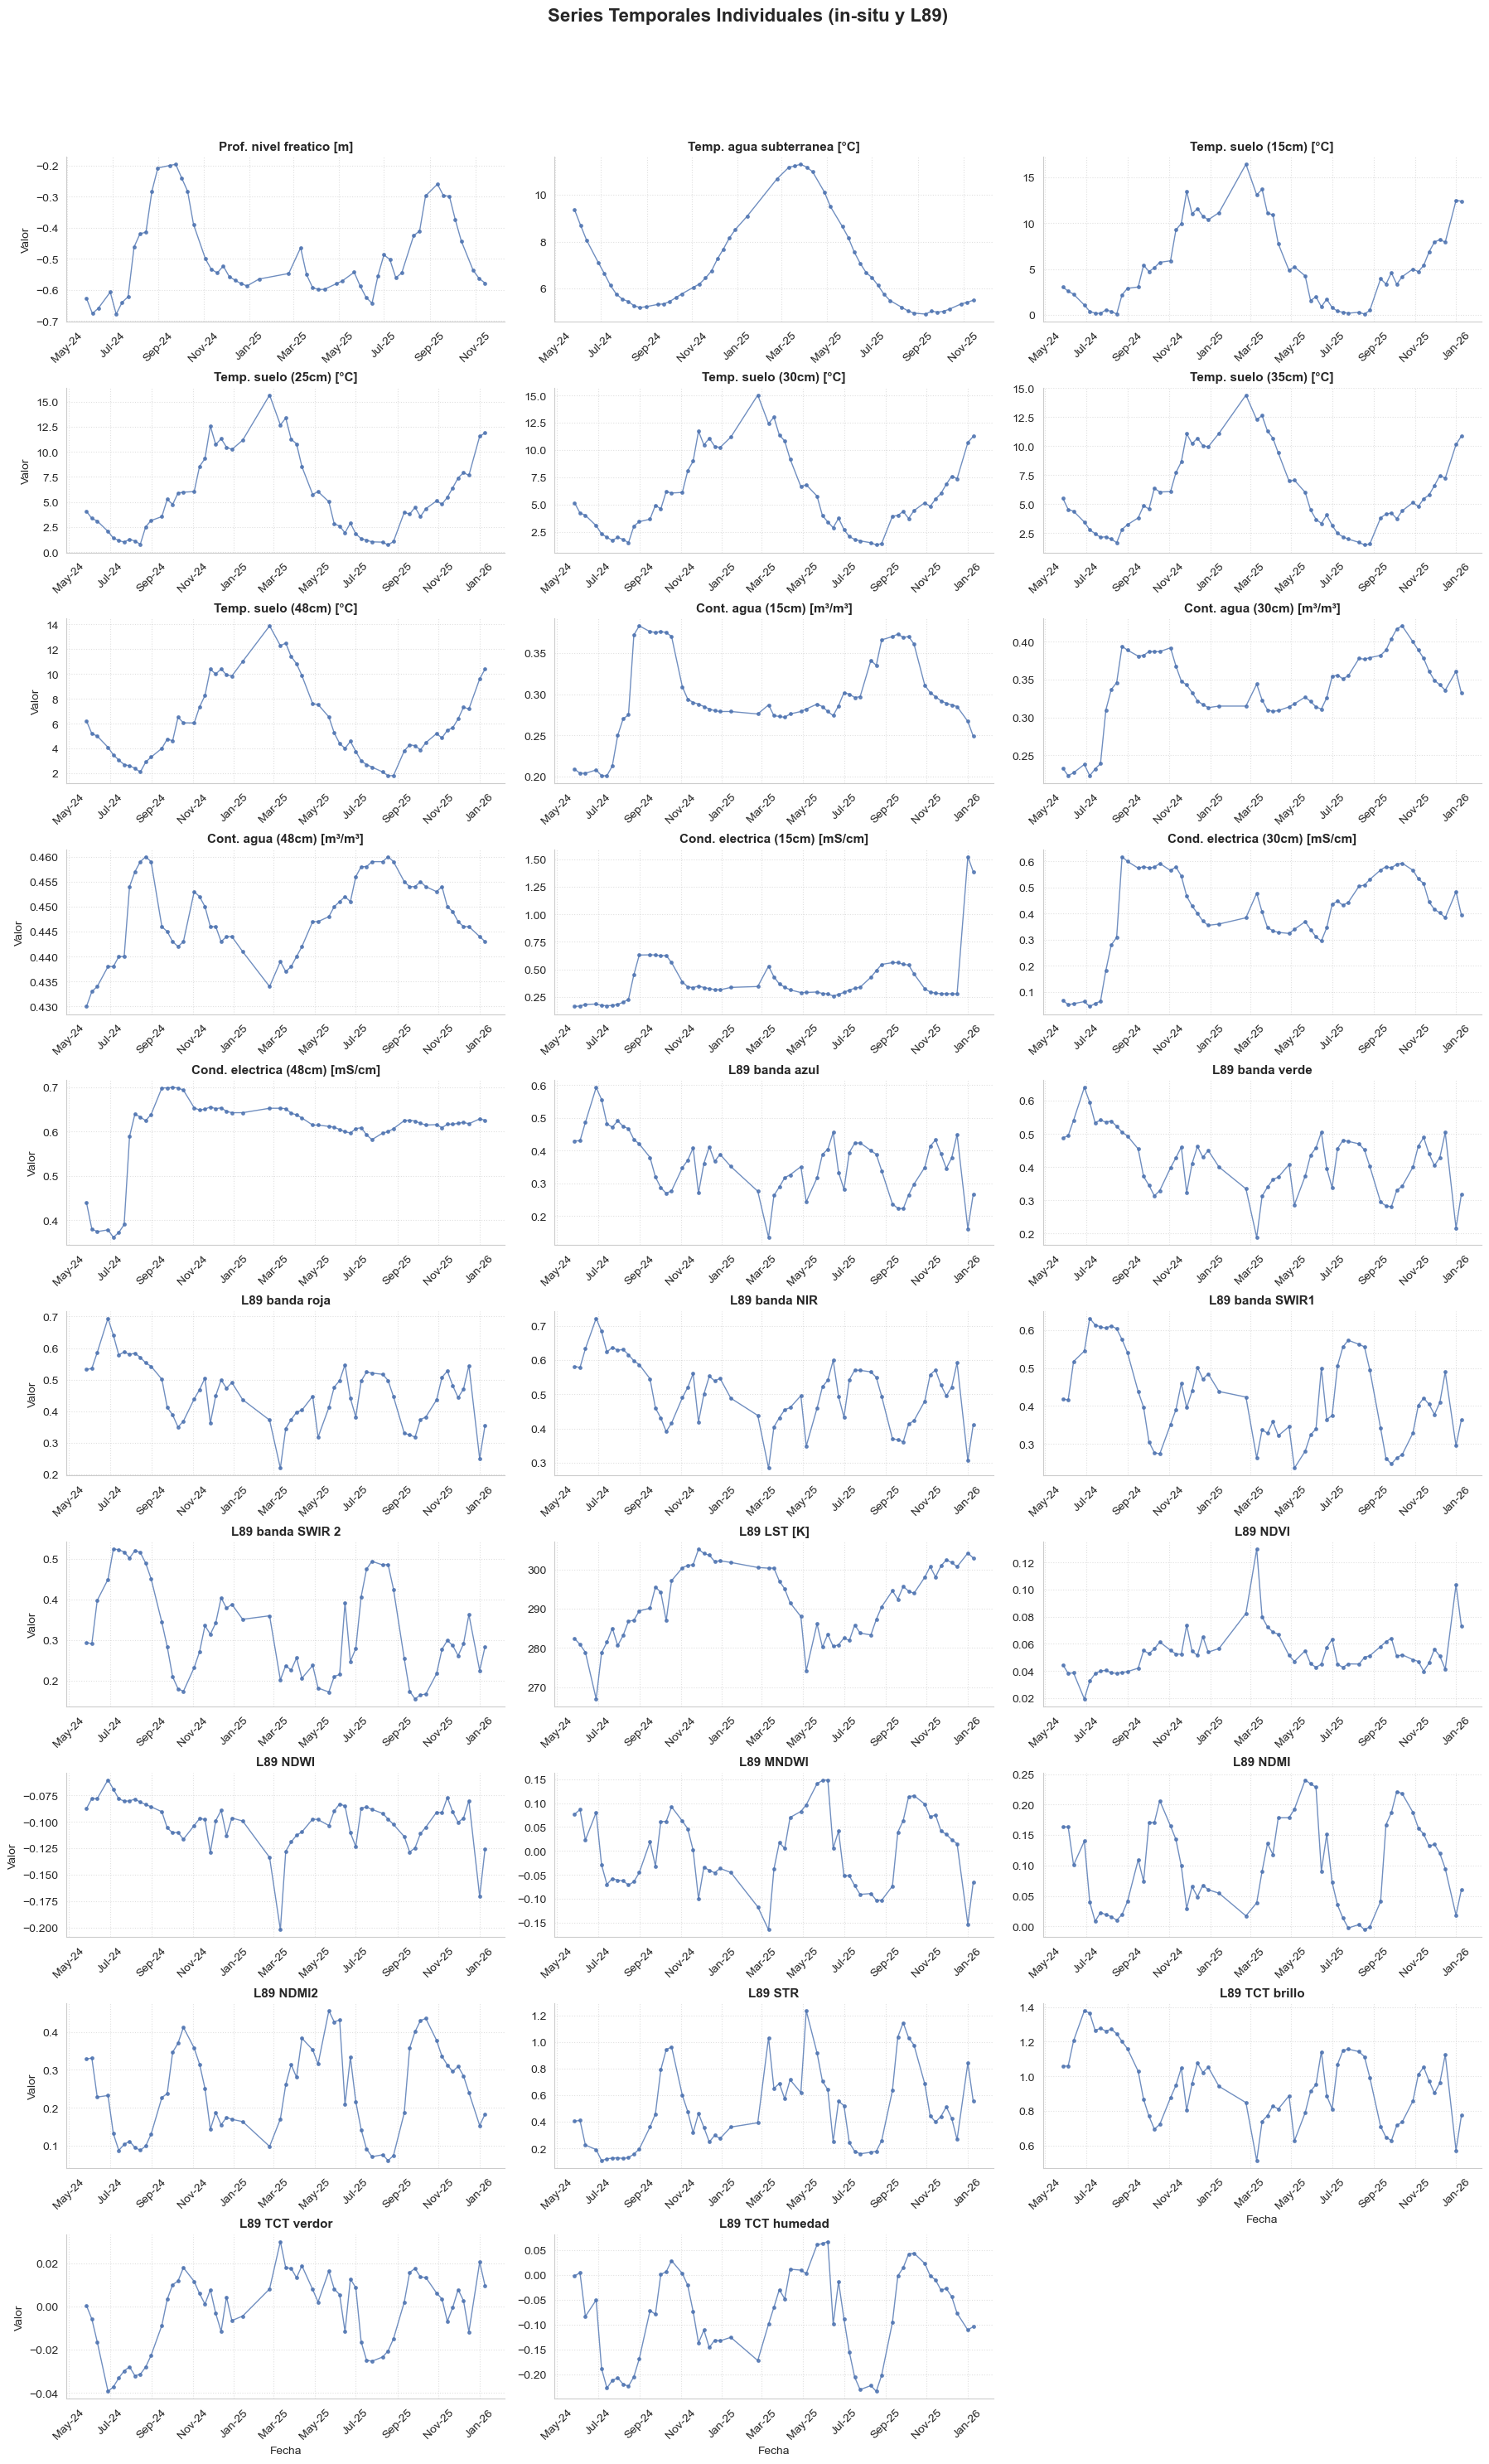

In [38]:
import matplotlib.dates as mdates

# ==========================================
# 6. GRAFICACIÓN DE SERIES TEMPORALES (FACETGRID)
# ==========================================

# 1. Preparación de datos (Importante: Incluir 'Timestamps')
# Filtramos solo las columnas válidas que existen en el DF
valid_vars = [v for v in vars_to_plot if v in df_sensor.columns]

# A diferencia del histograma, aquí necesitamos conservar la fecha para el eje X
cols_to_keep = ['Timestamps'] + valid_vars

# Convertimos a formato largo (Long format) preservando el tiempo
df_melted = df_sensor[cols_to_keep].melt(
    id_vars='Timestamps', 
    var_name='Variable_Tecnica', 
    value_name='Valor'
)

# 2. Aplicamos el MAPEO de nombres "Elegantes"
df_melted['Variable'] = df_melted['Variable_Tecnica'].map(lambda x: NAME_MAPPING.get(x, x))

# 3. Crear el Gráfico (FacetGrid)
g = sns.FacetGrid(
    df_melted, 
    col="Variable",      # Una sub-gráfica por variable
    col_wrap=3,          # Usamos 3 columnas para dar más ancho a cada serie temporal
    sharex=False,         # Compartir eje X facilita comparar eventos simultáneos
    sharey=False,        # Cada variable tiene su propia escala Y
    height=3.0,          # Altura moderada
    aspect=2.0           # Proporción ancha (panorámica) ideal para series de tiempo
)

# 4. Dibujar la serie temporal
# Usamos plt.plot para conectar puntos y poner marcadores
g.map(plt.plot, "Timestamps", "Valor", marker='.', linestyle='-', linewidth=1, markersize=5, color="#4C72B0", alpha=0.8)

# 5. Ajustes de Formato de Fechas y Estética
# Iteramos sobre cada subplot para formatear el eje X correctamente
for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y')) # Formato Mes-Año
    ax.tick_params(axis='x', rotation=45) # Rotar etiquetas para que no se solapen
    ax.grid(True, linestyle=':', alpha=0.6) # Añadir grilla suave

# 6. Títulos y Etiquetas finales
g.set_titles("{col_name}", size=11, weight='bold')
g.set_axis_labels("Fecha", "Valor")

plt.subplots_adjust(top=0.92, hspace=0.4) # Espacio para el título principal y entre filas
g.fig.suptitle(f'Series Temporales Individuales (in-situ y {SENSOR_ACTUAL.upper()})', fontsize=16, weight='bold')

plt.show()